# Задание 3. Реализация обхода в ширину из нескольких стартовых вершин (Multiple-Source BFS)

### Трубачеев Борис Андреевич, группа S4101

Выполнены все подпункты задания.

### Импорты 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import graphblas as gb
from graphblas import Matrix, Vector, Scalar
from graphblas import dtypes
from graphblas import unary, binary, monoid, semiring

## 1. Функция для подсчета mbfs levels и функция для подсчета в разных кольцах

Подсчет реализован в матричном виде для нескольких источников. Для удобства подсчеты в разных кольцах вынесены в рахные функции, хотя просто заменяют одну строчку с умножем в нужном кольце.

In [2]:
def msbfs_levels(A: Matrix, sources: list[int], sem) -> list[tuple[int, list[int]]]:
    """
    Принимает: матрицу смежности графа, список стартовых вершин и полукольцо.
    Возвращает: для каждой стартовой вершины список уровней до всех вершин,
    где 0 - сама вершина, -1 - недостижимые.
    """
    n = A.nrows
    k = len(sources)

    result = Matrix(dtypes.INT32, k, n)

    F = Matrix(bool, k, n)

    for i, s in enumerate(sources):
        F[i, s] = True

    level = 0
    succ = Scalar(bool)

    while True:
        level += 1

        result(mask=F) << level
        F(~result.S, replace=True) << F.mxm(A, sem)

        if F.nvals == 0:
            break

    output = []
    for i, s in enumerate(sources):
        dense = result[i, :].to_dense(fill_value=-1)
        
        levels = [int(x) - 1 if x != -1 else -1 for x in dense]
        levels[s] = 0

        output.append((s, levels))

    return output

def msbfs_levels_lor_land(A: Matrix, sources: list[int]):
    """
    Принимает: матрицу смежности и список стартовых вершин.
    Возвращает: уровни достижимости для каждой вершины, используя полукольцо lor_land.
    """
    return msbfs_levels(A, sources, semiring.lor_land)

def msbfs_levels_any_pair(A: Matrix, sources: list[int]):
    """
    Принимает: матрицу смежности и список стартовых вершин.
    Возвращает: уровни достижимости для каждой вершины, используя полукольцо any_pair.
    """
    return msbfs_levels(A, sources, semiring.any_pair)

## 2. Функция для подсчета mbfs parents и функции для подсчета в разных кольцах

Подсчет реализован в матричном виде для нескольких источников. Для удобства подсчеты в разных кольцах вынесены в рахные функции, хотя просто заменяют одну строчку с умножем в нужном кольце.

In [3]:
def msbfs_parents(A: Matrix, sources, sem):
    """
    Принимает: матрицу смежности, список стартовых вершин и полукольцо.
    Возвращает: для каждой стартовой вершины список родителей для кратчайших путей,
    где -1 — стартовая вершина, -2 — недостижимые.
    """
    N = A.nrows
    k = len(sources)

    index_ramp = Vector(dtypes.INT64, N)
    index_ramp.build(range(N), range(N))

    parents = Matrix(dtypes.INT64, k, N)
    wavefront = Matrix(dtypes.INT64, k, N)

    for i, s in enumerate(sources):
        parents[i, s] = s
        wavefront[i, s] = 1

    while wavefront.nvals > 0:
        for i in range(k):
            row = wavefront[i, :]
            row << index_ramp.ewise_mult(row, binary.first)

        next_wavefront = wavefront.mxm(A, sem)

        masked = Matrix(dtypes.INT64, k, N)
        masked(mask=~parents.S, replace=True) << next_wavefront

        parents(binary.min) << masked

        wavefront << masked

    result = []

    for i, s in enumerate(sources):
        row = parents[i, :].to_dense(fill_value=-2).tolist()

        for j in range(N):
            if j == s:
                row[j] = -1
            elif row[j] == j:
                row[j] = -1

        result.append((s, row))

    return result

def msbfs_parents_min_first(A: Matrix, sources: list[int]):
    """
    Принимает: матрицу смежности и список стартовых вершин.
    Возвращает: родителей вершин для кратчайших путей с использованием полукольца min_first.
    """
    return msbfs_parents(A, sources, semiring.min_first)

def msbfs_parents_any_first(A: Matrix, sources: list[int]):
    """
    Принимает: матрицу смежности и список стартовых вершин.
    Возвращает: родителей вершин для кратчайших путей с использованием полукольца any_first.
    """
    return msbfs_parents(A, sources, semiring.any_first)

## 3. Проверка корректноксти реализаций 

### Фукнции для генерации тест-кейсов

В тест-кейсах рассмотрены разные случаи графов (разрывные, цепочные, слабо разреженные) и разное кол-во начальных вершин

In [4]:
def numpy_to_graphblas(A: np.ndarray) -> gb.Matrix:
    """
    Принимает: numpy-матрицу смежности.
    Возвращает: такую же матрицу GraphBLAS.
    """
    rows, cols = np.where(A != 0)
    vals = A[rows, cols]
    return gb.Matrix.from_coo(rows, cols, vals, nrows=A.shape[0], ncols=A.shape[1])


def generate_bfs_test_cases():
    test_cases = []

    #1. Цепочка
    A = np.zeros((3, 3))
    A[0, 1] = 1
    A[1, 2] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 1, 2])],
        [(0, [-1, 0, 1])],
        "Цепочка"
    ))

    #2. Разрывный граф
    A = np.zeros((4, 4))
    A[0, 1] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 1, -1, -1])],
        [(0, [-1, 0, -2, -2])],
        "Разрыв"
    ))

    #3. Несколько источников (цепочка)
    A = np.zeros((4, 4))
    A[0, 1] = 1
    A[1, 2] = 1
    A[2, 3] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0, 2],
        [
            (0, [0, 1, 2, 3]),
            (2, [-1, -1, 0, 1])
        ],
        [
            (0, [-1, 0, 1, 2]),
            (2, [-2, -2, -1, 2])
        ],
        "Multi source цепочка"
    ))

    #4. Ромб
    A = np.zeros((4, 4))
    A[0, 1] = 1
    A[0, 2] = 1
    A[1, 3] = 1
    A[2, 3] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0, 1],
        [
            (0, [0, 1, 1, 2]),
            (1, [-1, 0, -1, 1])
        ],
        [
            (0, [-1, 0, 0, 1]),
            (1, [-2, -1, -2, 1])
        ],
        "Ромб multi-source"
    ))

    #5. Звезда
    A = np.zeros((5, 5))
    for i in range(1, 5):
        A[0, i] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0, 2],
        [
            (0, [0, 1, 1, 1, 1]),
            (2, [-1, -1, 0, -1, -1])
        ],
        [
            (0, [-1, 0, 0, 0, 0]),
            (2, [-2, -2, -1, -2, -2])
        ],
        "Звезда multi-source"
    ))

    #6. Цикл
    A = np.zeros((3, 3))
    A[0, 1] = 1
    A[1, 2] = 1
    A[2, 0] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0, 1],
        [
            (0, [0, 1, 2]),
            (1, [2, 0, 1])
        ],
        [
            (0, [-1, 0, 1]),
            (1, [2, -1, 1])
        ],
        "Цикл multi-source"
    ))

    #7. Два компонента
    A = np.zeros((6, 6))
    A[0, 1] = 1
    A[1, 2] = 1
    A[3, 4] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0, 3],
        [
            (0, [0, 1, 2, -1, -1, -1]),
            (3, [-1, -1, -1, 0, 1, -1])
        ],
        [
            (0, [-1, 0, 1, -2, -2, -2]),
            (3, [-2, -2, -2, -1, 3, -2])
        ],
        "Два компонента"
    ))

    #8. Полный граф (важный кейс)
    A = np.ones((4, 4)) - np.eye(4)

    test_cases.append((
        numpy_to_graphblas(A),
        [0, 1],
        [
            (0, [0, 1, 1, 1]),
            (1, [1, 0, 1, 1])
        ],
        [
            (0, [-1, 0, 0, 0]),
            (1, [1, -1, 1, 1])
        ],
        "Полный граф"
    ))

    #9. Все вершины как старт
    A = np.zeros((4, 4))
    A[0, 1] = 1
    A[1, 2] = 1
    A[2, 3] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0, 1, 2, 3],
        [
            (0, [0, 1, 2, 3]),
            (1, [-1, 0, 1, 2]),
            (2, [-1, -1, 0, 1]),
            (3, [-1, -1, -1, 0])
        ],
        [
            (0, [-1, 0, 1, 2]),
            (1, [-2, -1, 1, 2]),
            (2, [-2, -2, -1, 2]),
            (3, [-2, -2, -2, -1])
        ],
        "Все вершины старт"
    ))

    #10. Одиночная вершина
    A = np.zeros((1, 1))

    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0])],
        [(0, [-1])],
        "Одиночная вершина"
    ))

    return test_cases

### Функция запуска тестов

Может запускать тесты как для levels, так и для parents. При несовпадении результатов в assert не падает, а выдает сообщение об ошибке, т.к. для некоторых алгоритмов результат может быть не детерминирован (увидим это далее). Если все тесты прошли -- выводит об этом сообщение

In [5]:
def run_tests(func, algorithm):
    """
    Принимает: функцию и тип алгоритма, проверяет корректность работы функции на наборе тестов.
    Выводит сообщение об ошибке для упавших тестов или что все тесты пройдены.
    """
    test_cases = generate_bfs_test_cases()
    succ_flg = True
    for A, sources, expected_levels, expected_parents, name in test_cases:
        result = func(A, sources)
        if algorithm == 'levels':
            expected = expected_levels
        else:
            expected = expected_parents
        try:
            assert result == expected, (
                    f"Ттест {name} упал: {expected_parents} != {result}.\n\n Матрица смежности: {A}"
                )
        except Exception as e:
            print(str(e))
            succ_flg = False
            continue
    if succ_flg:
        print(f"{func.__name__} -- все тесты пройдены!")

### Запускаем тесты для mbfs levels в "стандартном" полукольце lor_land

Все тесты пройдены успешно

In [6]:
run_tests(msbfs_levels_lor_land, 'levels')

msbfs_levels_lor_land -- все тесты пройдены!


### Запускаем тесты для mbfs parents в "стандартном" полукольце min_first

Все тесты пройдены успешно

In [7]:
run_tests(msbfs_parents_min_first, 'parents')

msbfs_parents_min_first -- все тесты пройдены!


## 4. Реализация в полукольцах any_pair для levels и any_first для parents (+3)

Т.к. реализации были написаны в матричном виде, то для изменения полукольца достаточно изменить его в операциях, возможность чего изначально заложили в функции подсчета. Тогда просто вызываем тесты в нужных нам полукольцах (фунции для этого также написапны в пунктах 1 и 2)

### Запускаем тесты для mbfs levels в полукольце any_pair

Все тесты пройдены успешно

In [8]:
run_tests(msbfs_levels_any_pair, 'levels')

msbfs_levels_any_pair -- все тесты пройдены!


### Запускаем тесты для mbfs parents в  полукольце any_first

Упали на одном из тестов. Однако если посмотрть на матрицу смежности, то алгоритм выдал правильный ответ, он выдал предыдущую вершину (2), но не минимального (1),  т.к. операция any не подразумевает поиск миниального, а просто выдает факт связи, из-за чего алгоритм в этом полукольце недетерминирован, и это корректное поведение алгоритма в этом полукольце.

Итог: тест не пройден из-за недетерминированности алгоритма, но ответ правильный и функция работает корректно.

In [9]:
run_tests(msbfs_parents_any_first, 'parents')

Ттест Ромб multi-source упал: [(0, [-1, 0, 0, 1]), (1, [-2, -1, -2, 1])] != [(0, [-1, 0, 0, 2]), (1, [-2, -1, -2, 1])].

 Матрица смежности: "M_120"    nvals  nrows  ncols  dtype         format
gb.Matrix      4      4      4   FP64  bitmapr (iso)
----------------------------------------------------
  0    1    2    3
0    1.0  1.0     
1              1.0
2              1.0
3                 


### Итого: в исследуемых полукольцах функции работают корректно. Сравнение алгоритмов в разных полукольцах будет приведено ниже после запуска стресс тестов

## 5. Экспериментальное исследование полученных реализаций (+2)

Исследовать будем на скаченных графах и на случайно сгенерированных функцией из предыдущего задания.

### Функция загрузки скаченных графов

In [10]:
from scipy.io import mmread


def load_graphblas_from_mtx(path: str) -> gb.Matrix:
    """
    Загружает .mtx файл по пути path в graphblas.Matrix
    """
    M = mmread(path).tocsr()
    
    rows, cols = M.nonzero()
    vals = M.data
    
    n = M.shape[0]
    
    A = gb.Matrix.from_coo(rows, cols, vals, nrows=n, ncols=n)
    A = A - gb.Matrix.diag(A.diag())
    
    return A

### Функция засекания времени работы

In [11]:
import time

def measure_time(func, A, sources):
    start = time.perf_counter()
    result = func(A, sources)
    end = time.perf_counter()
    
    return end - start, result

### Функция прогонки стресс тестов и запси результатов на скаченных графах

In [12]:
import os

def benchmark_downloaded_graphs(algorithms, graphs_dir: str):
    """
    Прогоняет все алгоритмы по всем графам в папке
    и возвращает DataFrame с результататтами
    """
    
    records = []
    
    for filename in os.listdir(graphs_dir):
        if not filename.endswith(".mtx"):
            continue
        path = os.path.join(graphs_dir, filename)
        
        print(filename)
        
        A = load_graphblas_from_mtx(path)
        
        n = A.nrows
        nnz = A.nvals

        
        for func in algorithms:
            sources_cnt = np.ceil(np.logspace(1, np.log10(250), 8)).astype(int)
            for source_cnt in sources_cnt:
                sources = [i for i in range(source_cnt) if i < n]
                time_spent, res = measure_time(func, A, sources)

                records.append({
                    "graph": filename,
                    "algorithm": func.__name__,
                    "n_vertices": n,
                    "nnz": nnz,
                    "p": nnz / n,
                    "sources_cnt": len(sources),
                    "time_sec": time_spent
                })
    
    df = pd.DataFrame(records)
    
    return df

### Функция генерации случайного графа по вероятности ребра и кол-ву вершин

In [13]:
def generate_random_graph(n: int, p: float, seed=None, batch_size=1_000_000):
    """
    Принимает кол-во вершин n и вероятность возникновения ребра p.
    Возвращает граф в формате gb.Matrix
    """
    try:
        rng = np.random.default_rng(seed)
        
        # ожидаемое число рёбер
        max_edges = n * (n - 1) // 2
        expected_edges = int(max_edges * p)
        
        rows = []
        cols = []
        
        generated = 0
        
        while generated < expected_edges:
            size = min(batch_size, expected_edges - generated)
            
            i = rng.integers(0, n, size=size, dtype=np.int64)
            j = rng.integers(0, n, size=size, dtype=np.int64)
            
            # убираем петли
            mask = i != j
            i = i[mask]
            j = j[mask]
            
            # берём только i < j (верхний треугольник)
            mask = i < j
            i = i[mask]
            j = j[mask]
            
            rows.append(i)
            cols.append(j)
            
            generated += len(i)
        
        # объединяем
        rows = np.concatenate(rows)
        cols = np.concatenate(cols)
        
        # делаем симметричным
        rows_full = np.concatenate([rows, cols])
        cols_full = np.concatenate([cols, rows])
        
        # создаём sparse матрицу
        A = gb.Matrix.from_coo(
            rows_full,
            cols_full,
            [1] * len(rows_full),
            nrows=n,
            ncols=n,
            dup_op=gb.binary.max
        )

        return A
    except Exception as e:
        print(f"Не удалось создать матрицу {n} вершин с вероятностью {p}, ошибка: {repr(e)}")
        
    

### Функция запуска и записи результатов стресс теста для случайных графов

In [14]:
def benchmark_random_graphs(algorithms, n_values, p_values):
    """
    Получает на вход список кол-ва вершин, список вероятностей возникновения ребер.

    Возвращает датафрейм со статистиками работы каждого алгоритма
    """
    
    records = []
    
    for n in n_values:                      
        for p in p_values:
            
            A = generate_random_graph(n, p, seed=42)
            if A is None:
                continue
            
            nnz = A.nvals
            
            for func in algorithms:
                sources_cnt = np.ceil(np.logspace(1, np.log10(250), 8)).astype(int)
                for source_cnt in sources_cnt:
                    sources = [i for i in range(source_cnt) if i < n]

                    start = time.perf_counter()
                    res = func(A, sources)
                    end = time.perf_counter()
    
                    records.append({
                        "graph": f'random_{n}_{p}',
                        "algorithm": func.__name__,
                        "n_vertices": n,
                        "nnz": nnz,
                        "p": p,
                        "sources_cnt": len(sources),
                        "time_sec": end - start
                    })
    
                print(f"n={n}, p={p}, {func.__name__}, time: {(end - start):.3f}")
    
    return pd.DataFrame(records)

### Функция запуска и записи результатов стресс теста для всех графов (скаченных и случайных)

In [15]:
def benchmark_all_graphs(algorithms, graphs_dir):
    """
    Принимает список алгоритмов и путь к папке с графами 
    и запускает бенчмарки на скачанных и случайных графах.
    Возвращает: объединённый датафрейм с результатами всех экспериментов.
    """
    df_downloaded = benchmark_downloaded_graphs(algorithms, graphs_dir)
    
    n_values =  np.logspace(np.log10(100), np.log10(75000), 10).astype(int)
    p_values = [0.0001, 0.001, 0.01, 0.1]
    df_rnd = benchmark_random_graphs(algorithms, n_values, p_values)

    res = pd.concat([df_downloaded, df_rnd])

    return res


### Получаем резудльтаты времени работы алгоритмов levels и parents в "стандартных" полукольцах

In [16]:
result = benchmark_all_graphs([msbfs_levels_lor_land, msbfs_parents_min_first], 
                              "../../Graph Analysis/Lab3/graphs")

Erdos991.mtx
EX1.mtx
mycielskian10.mtx
mycielskian7.mtx
mycielskian8.mtx
mycielskian9.mtx
sphere3.mtx
Не удалось создать матрицу 100 вершин с вероятностью 0.0001, ошибка: ValueError('need at least one array to concatenate')
n=100, p=0.001, msbfs_levels_lor_land, time: 0.011
n=100, p=0.001, msbfs_parents_min_first, time: 0.028
n=100, p=0.01, msbfs_levels_lor_land, time: 0.011
n=100, p=0.01, msbfs_parents_min_first, time: 0.067
n=100, p=0.1, msbfs_levels_lor_land, time: 0.007
n=100, p=0.1, msbfs_parents_min_first, time: 0.034
n=208, p=0.0001, msbfs_levels_lor_land, time: 0.024
n=208, p=0.0001, msbfs_parents_min_first, time: 0.048
n=208, p=0.001, msbfs_levels_lor_land, time: 0.025
n=208, p=0.001, msbfs_parents_min_first, time: 0.059
n=208, p=0.01, msbfs_levels_lor_land, time: 0.026
n=208, p=0.01, msbfs_parents_min_first, time: 0.210
n=208, p=0.1, msbfs_levels_lor_land, time: 0.018
n=208, p=0.1, msbfs_parents_min_first, time: 0.067
n=435, p=0.0001, msbfs_levels_lor_land, time: 0.030
n=435,

In [17]:
result.head(5)

,graph,algorithm,n_vertices,nnz,p,sources_cnt,time_sec
0,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,10,0.003601
1,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,16,0.003501
2,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,26,0.007884
3,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,40,0.007790
4,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,63,0.012557


###  Получаем резудльтаты времени работы алгоритмов levels и parents в полукольцах anypair для levels и any_first для parents

In [18]:
result_any = benchmark_all_graphs([msbfs_levels_any_pair, msbfs_parents_any_first],
                                   "../../Graph Analysis/Lab3/graphs")

Erdos991.mtx
EX1.mtx
mycielskian10.mtx
mycielskian7.mtx
mycielskian8.mtx
mycielskian9.mtx
sphere3.mtx
Не удалось создать матрицу 100 вершин с вероятностью 0.0001, ошибка: ValueError('need at least one array to concatenate')
n=100, p=0.001, msbfs_levels_any_pair, time: 0.010
n=100, p=0.001, msbfs_parents_any_first, time: 0.035
n=100, p=0.01, msbfs_levels_any_pair, time: 0.014
n=100, p=0.01, msbfs_parents_any_first, time: 0.082
n=100, p=0.1, msbfs_levels_any_pair, time: 0.008
n=100, p=0.1, msbfs_parents_any_first, time: 0.042
n=208, p=0.0001, msbfs_levels_any_pair, time: 0.023
n=208, p=0.0001, msbfs_parents_any_first, time: 0.053
n=208, p=0.001, msbfs_levels_any_pair, time: 0.027
n=208, p=0.001, msbfs_parents_any_first, time: 0.061
n=208, p=0.01, msbfs_levels_any_pair, time: 0.033
n=208, p=0.01, msbfs_parents_any_first, time: 0.271
n=208, p=0.1, msbfs_levels_any_pair, time: 0.018
n=208, p=0.1, msbfs_parents_any_first, time: 0.065
n=435, p=0.0001, msbfs_levels_any_pair, time: 0.030
n=435,

In [19]:
result_any.head(5)

,graph,algorithm,n_vertices,nnz,p,sources_cnt,time_sec
0,Erdos991.mtx,msbfs_levels_any_pair,492,2834,5.760163,10,0.007426
1,Erdos991.mtx,msbfs_levels_any_pair,492,2834,5.760163,16,0.004995
2,Erdos991.mtx,msbfs_levels_any_pair,492,2834,5.760163,26,0.006694
3,Erdos991.mtx,msbfs_levels_any_pair,492,2834,5.760163,40,0.008300
4,Erdos991.mtx,msbfs_levels_any_pair,492,2834,5.760163,63,0.011802


### Соединяем результаты в один датафрейм

In [20]:
df = pd.concat([result, result_any])
df

,graph,algorithm,n_vertices,nnz,p,sources_cnt,time_sec
0,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,10,0.003601
1,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,16,0.003501
2,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,26,0.007884
3,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,40,0.007790
4,Erdos991.mtx,msbfs_levels_lor_land,492,2834,5.760163,63,0.012557
...,...,...,...,...,...,...,...
619,random_75000_0.1,msbfs_parents_any_first,75000,535288522,0.100000,40,1.283528
620,random_75000_0.1,msbfs_parents_any_first,75000,535288522,0.100000,63,1.863759
621,random_75000_0.1,msbfs_parents_any_first,75000,535288522,0.100000,100,3.023407
622,random_75000_0.1,msbfs_parents_any_first,75000,535288522,0.100000,158,4.958463


### Функции отрисовки графиков времени от разных параметров графов и алгоритмов

In [21]:
def plot_time_vs_size(df):
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df,
        x="n_vertices",
        y="time_sec",
        hue="algorithm",
        marker="o",
        errorbar=None
    )

    plt.title("Время работы vs размер графа")
    plt.xlabel("Число вершин")
    plt.ylabel("Время (сек)")
    plt.tight_layout()
    plt.show()

def plot_time_vs_edges(df):
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df,
        x="nnz",
        y="time_sec",
        hue="algorithm",
        marker="o",
        errorbar=None
    )

    plt.title("Время работы vs число рёбер")
    plt.xlabel("nnz")
    plt.ylabel("Время (сек)")
    plt.xscale("log")
    plt.tight_layout()
    plt.show()

def plot_time_vs_density(df):
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="p",
        y="time_sec",
        hue="algorithm"
    )

    sns.stripplot(
        data=df,
        x="p",
        y="time_sec",
        hue="algorithm",
        dodge=True,
        alpha=0.5,
        color="black"
    )

    plt.title("Время работы vs разреженность графа")
    plt.xlabel("p = nnz / n")
    plt.ylabel("Время (сек)")
    plt.yscale("log")
    plt.legend(title="Алгоритм", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

def plot_time_vs_density_mean(df):
    grouped = (
        df.groupby(["p", "algorithm"])["time_sec"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=grouped,
        x="p",
        y="time_sec",
        hue="algorithm",
        marker="o"
    )

    plt.title("Среднее время vs разреженность")
    plt.xlabel("p")
    plt.ylabel("Среднее время (сек)")
    plt.xscale("log")
    plt.tight_layout()
    plt.show()

def plot_time_vs_sources(df):
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df,
        x="sources_cnt",
        y="time_sec",
        hue="algorithm",
        marker="o",
        errorbar=None
    )

    plt.title("Время работы vs число источников")
    plt.xlabel("Количество источников")
    plt.ylabel("Время (сек)")
    plt.tight_layout()
    plt.show()

def plot_algorithm_comparison(df):
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="algorithm",
        y="time_sec"
    )

    plt.title("Сравнение алгоритмов")
    plt.xlabel("Алгоритм")
    plt.ylabel("Время (сек)")
    plt.xticks(rotation=30)
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

def plot_facet(df):
    g = sns.relplot(
        data=df[df['p'].isin([0.0001, 0.001, 0.01, 0.1])],
        x="n_vertices",
        y="time_sec",
        hue="algorithm",
        col="p",
        kind="line",
        marker="o",
        errorbar=None,
        col_wrap=2
    )

    g.fig.suptitle("Время vs размер графа при разных p", y=1.02)

### Отрисовываем графики зависимостей

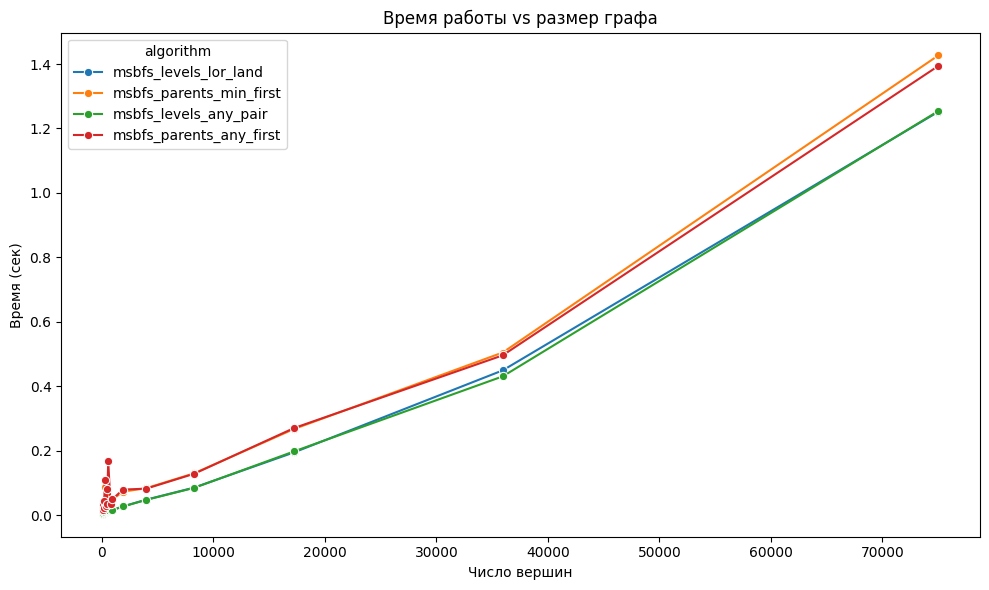

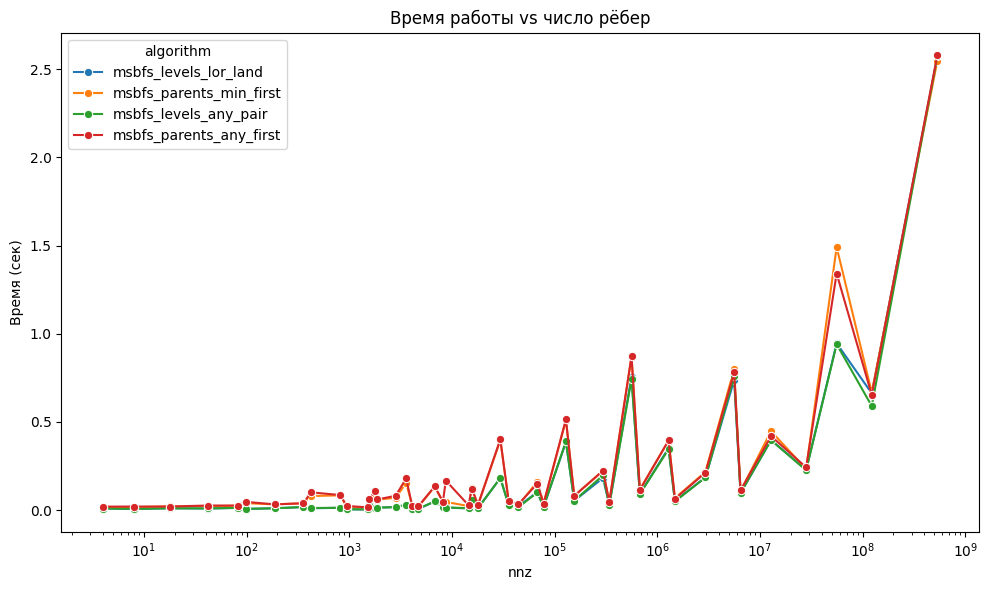

C:\Users\boris\AppData\Local\Temp\ipykernel_27144\2349129907.py:48: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


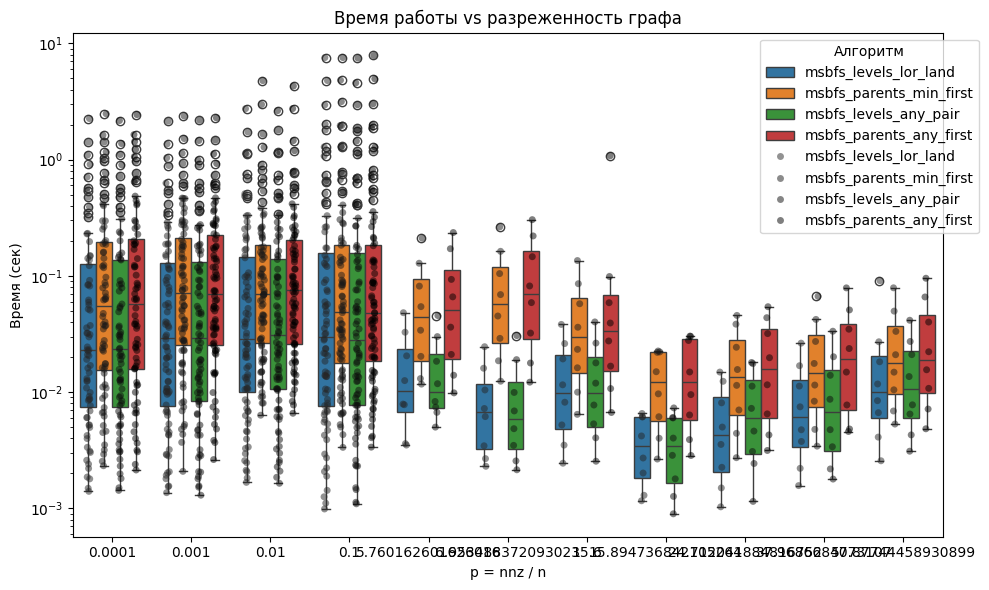

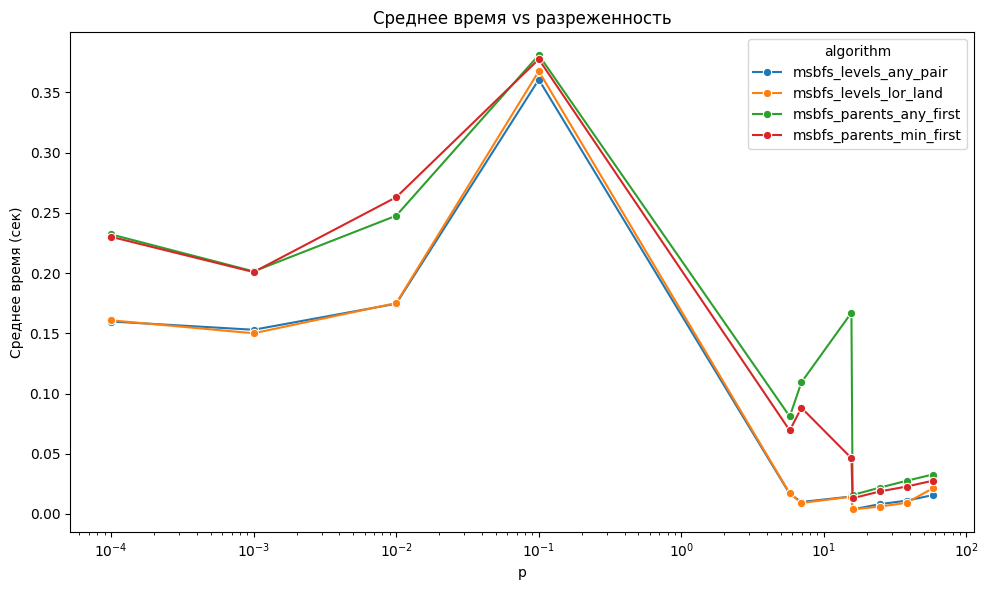

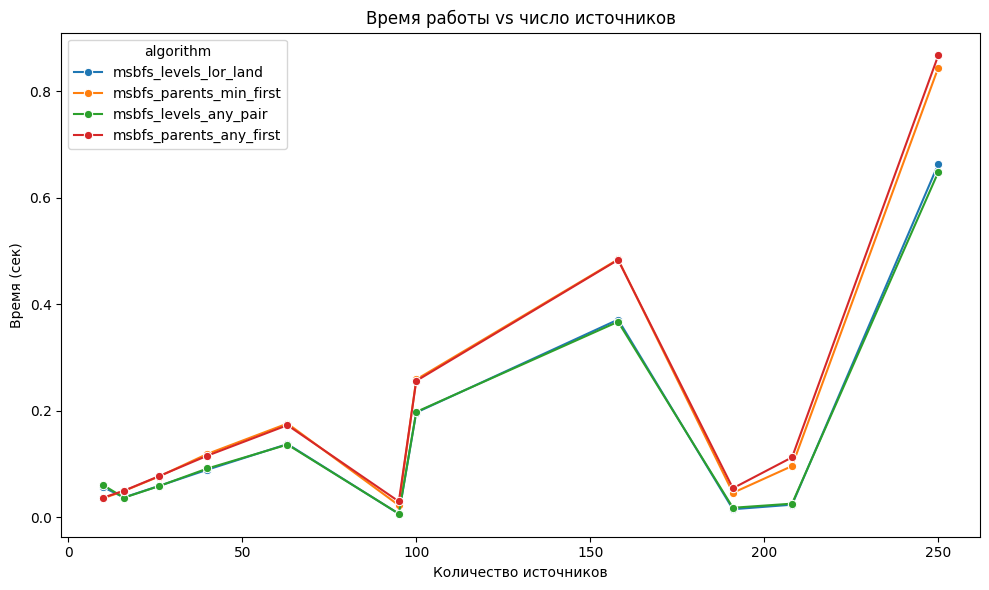

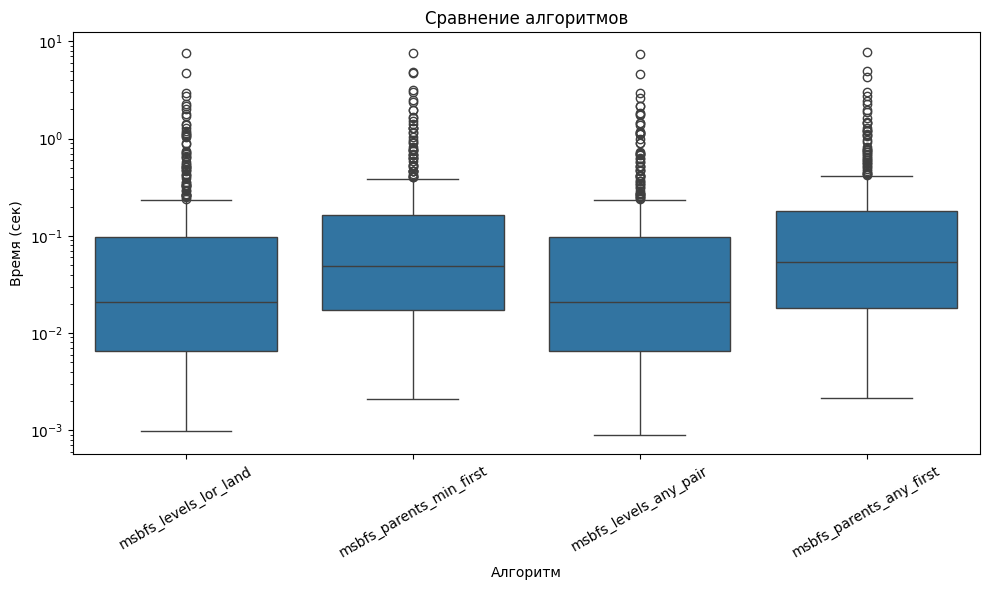

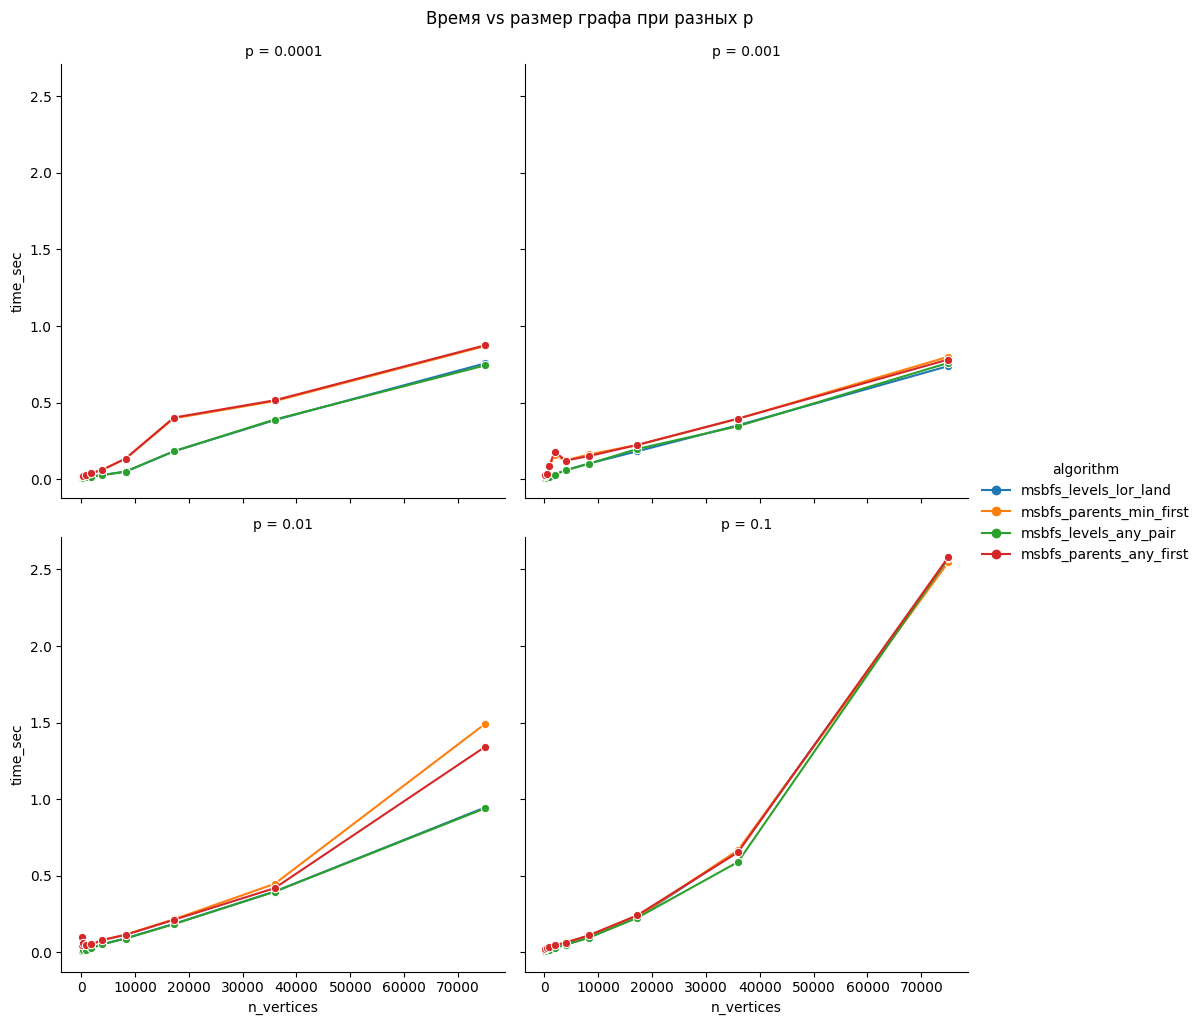

In [22]:
plot_time_vs_size(df)
plot_time_vs_edges(df)
plot_time_vs_density(df)
plot_time_vs_density_mean(df)
plot_time_vs_sources(df)
plot_algorithm_comparison(df)
plot_facet(df)

## Выводы по зависимости алгоритмов от параметров

1. По графикам видим слабую степенную зависимость между кол-вом вершин и временем работы алгоритмов (график 1). Однако, на последнем графике заметно, что чем выше степень разреженности графа, тем более выражена степенная зависимость времени от количества вершин (при p=10^-4 и 10^-3 зависимость больше похожа на линейную и при p=0.01 и 0.1 зависимость все больше становится степенной)
2. Прямой зависимости времени работы от степени разреженности p нет, т.к. эксперементы проводились с разным кол-вом вершин (графики 3 и 4). Т.к. матрицы в библиотеке исползуются в coo представлении, то зависимость имеется именно от сочетания факторов кол-ва вершин и разреженности, т.е. числа ребер в графе, что усложняет подсчет произведения матриц в этом представлении. Поэтому степенная зависимоть есть именно от кол-ва ребер (график 2).
3. От числа источников также присутсвует возрастающая зависимость времени (график 5). Данная зависимость ведет себя странно, т.к. "скачет" в зависимости от числа источников, но в оченьмаленьком диапазоне (0.3 сек). Данная странность скорее всего связана с релазацией матричиного умножения разреженных матриц - в общем с числом ненулевых элементов матрицы время должно возрастать, поэтому с числом источников появляются дополнительные ряды при умножении матриц и время растет, но обрывисто, вероятно из-за внутренних процессов оптимизатора умножения разреженных матриц.

## Выводы по сравнению алгоритмов

1. Исходя из всех графиков разница во времени работы алгоримов в "стандартных" и "нестандартных" кольцах минимальна и сопоставима с погрещшностью, что логично, т.к. мы просто меняем операции в полукольце.
2. Алгоритм levels работает чуть быстрее parents.

# Вывод по работе

Все пункты задания выполнены, все требуемые реализации получены, и проведены все требуемые сравнения на эксперементах. 